Introduction to Python Imaging Library(PIL)

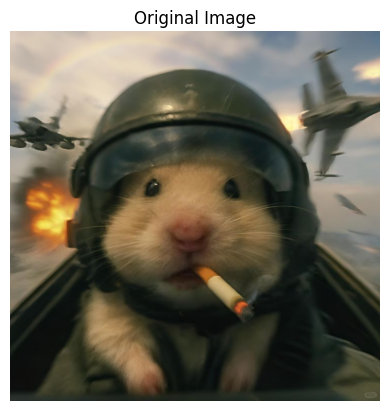

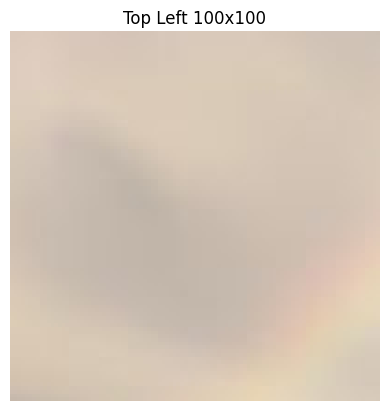

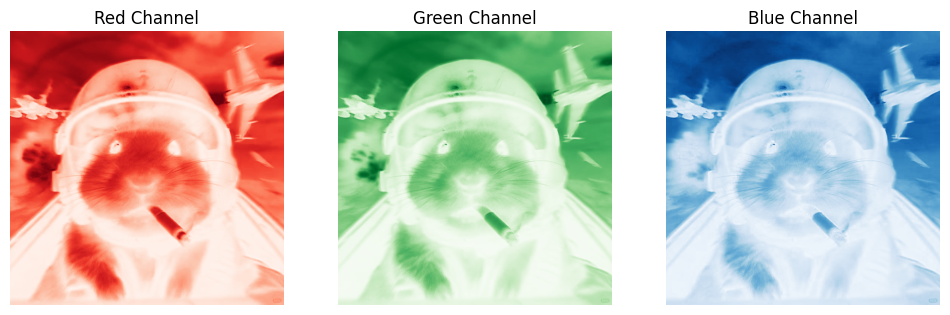

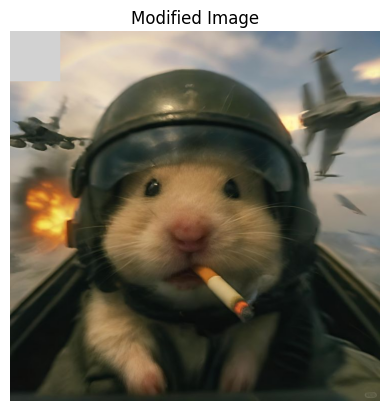

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# Load image

img = Image.open("/content/drive/MyDrive/AI and Machine Learning/download (2).jpg")
img_array = np.array(img)

# Display image
plt.imshow(img_array)
plt.title("Original Image")
plt.axis("off")
plt.show()

# Top left 100x100 pixels
top_left = img_array[0:100,0:100]

plt.imshow(top_left)
plt.title("Top Left 100x100")
plt.axis("off")
plt.show()

# RGB Channels
R = img_array[:,:,0]
G = img_array[:,:,1]
B = img_array[:,:,2]

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(R, cmap="Reds")
plt.title("Red Channel")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(G, cmap="Greens")
plt.title("Green Channel")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(B, cmap="Blues")
plt.title("Blue Channel")
plt.axis("off")

plt.show()

# Modify top-left 100x100 pixels
modified = img_array.copy()
modified[0:100,0:100] = 210

plt.imshow(modified)
plt.title("Modified Image")
plt.axis("off")
plt.show()

Exercise - 2:

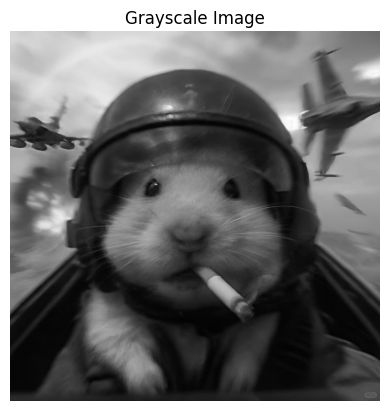

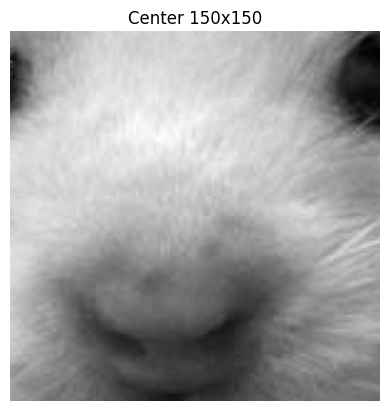

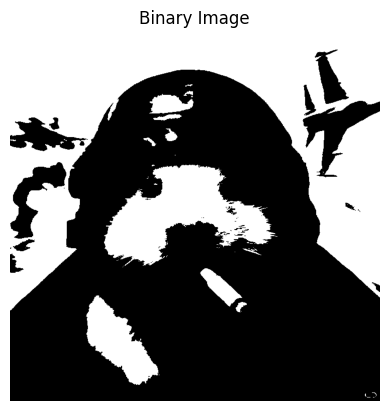

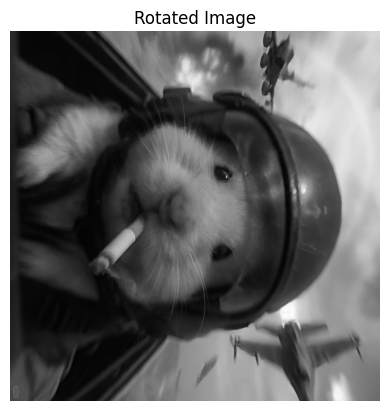

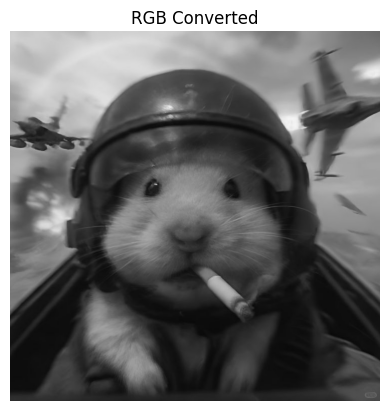

In [2]:
# Convert to grayscale
gray = Image.open("/content/drive/MyDrive/AI and Machine Learning/download (2).jpg").convert("L")
gray_array = np.array(gray)

plt.imshow(gray_array, cmap="gray")
plt.title("Grayscale Image")
plt.axis("off")
plt.show()

# Extract center 150 pixels
h, w = gray_array.shape
center = gray_array[h//2-75:h//2+75, w//2-75:w//2+75]

plt.imshow(center, cmap="gray")
plt.title("Center 150x150")
plt.axis("off")
plt.show()

# Threshold
binary = gray_array.copy()
binary[binary < 100] = 0
binary[binary >= 100] = 255

plt.imshow(binary, cmap="gray")
plt.title("Binary Image")
plt.axis("off")
plt.show()

# Rotate image
rotated = gray.rotate(-90)

plt.imshow(rotated, cmap="gray")
plt.title("Rotated Image")
plt.axis("off")
plt.show()

# Convert grayscale to RGB
rgb = np.stack((gray_array,)*3, axis=-1)

plt.imshow(rgb)
plt.title("RGB Converted")
plt.axis("off")
plt.show()

Exercise 3 PCA Compression Code

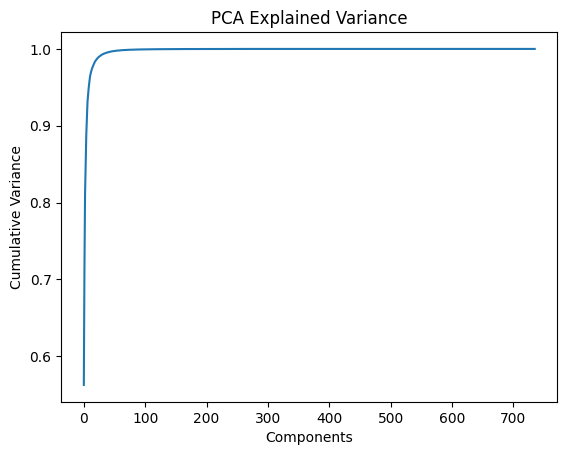

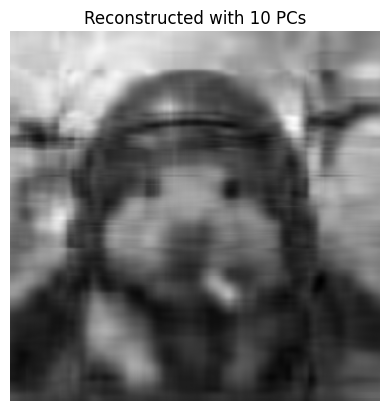

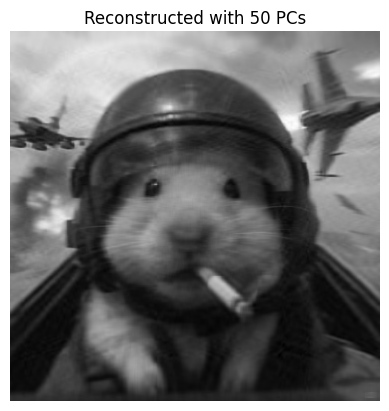

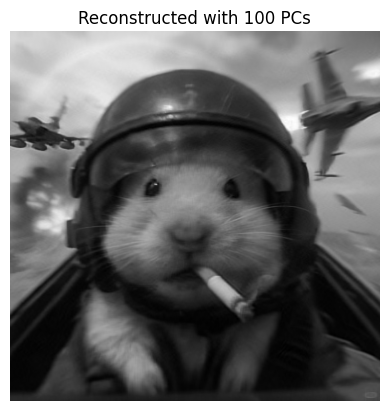

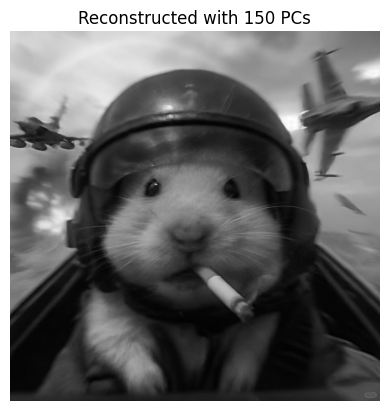

In [3]:
# Convert to grayscale
img = Image.open("/content/drive/MyDrive/AI and Machine Learning/download (2).jpg").convert("L")
img = np.array(img)

# Center data
mean = np.mean(img, axis=0)
X = img - mean

# Covariance matrix
cov = np.cov(X, rowvar=False)

# Eigen decomposition
eigenvalues, eigenvectors = np.linalg.eig(cov)

# Sort
idx = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:,idx]

# Explained variance
explained = eigenvalues / np.sum(eigenvalues)
cumulative = np.cumsum(explained)

plt.plot(cumulative)
plt.xlabel("Components")
plt.ylabel("Cumulative Variance")
plt.title("PCA Explained Variance")
plt.show()

# Reconstruction
components = [10,50,100,150]

for k in components:

    W = eigenvectors[:,:k]

    compressed = np.dot(X,W)
    reconstructed = np.dot(compressed,W.T) + mean

    plt.imshow(reconstructed, cmap="gray")
    plt.title(f"Reconstructed with {k} PCs")
    plt.axis("off")
    plt.show()